First 5 rows:
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


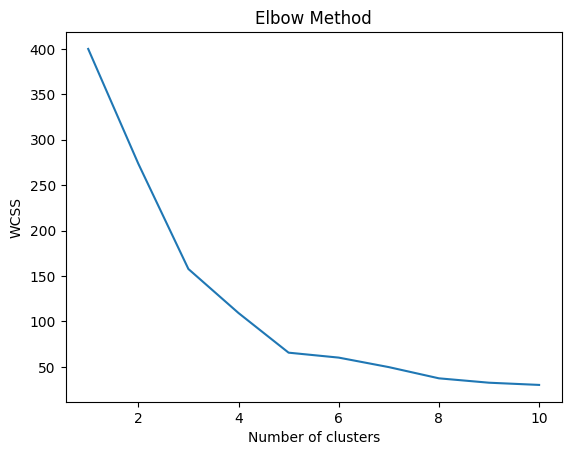


K-Means Silhouette Score: 0.5546571631111091
DBSCAN Silhouette Score: 0.3875583892728279


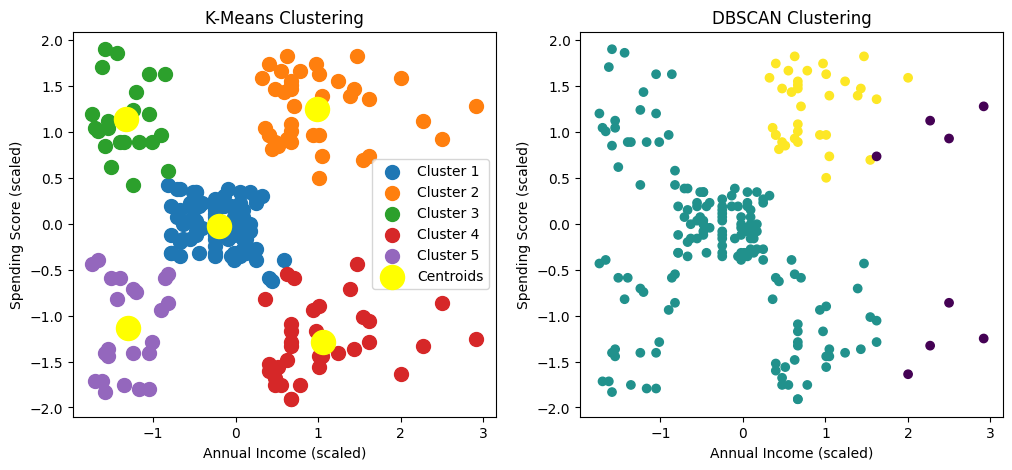

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score


dataset = pd.read_csv('Mall_Customers.csv')

print("First 5 rows:\n", dataset.head())



# Select features: Annual Income & Spending Score
X = dataset.iloc[:, [3, 4]].values

# Feature Scaling (IMPORTANT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)


wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


kmeans_score = silhouette_score(X_scaled, y_kmeans)
print("\nK-Means Silhouette Score:", kmeans_score)

dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

valid = y_dbscan != -1

if len(set(y_dbscan[valid])) > 1:
    dbscan_score = silhouette_score(X_scaled[valid], y_dbscan[valid])
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN could not form proper clusters")


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=100, label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=100, label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=100, label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], s=100, label='Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], s=100, label='Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()

# DBSCAN Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_dbscan)
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')

plt.show()